# 10.000 burbujas programables — músculos artificiales controlados con ultrasonido

Cada burbuja mide menos que un cabello humano. Su tamaño determina a qué frecuencia de ultrasonido vibra. Juntas, forman un músculo que responde en 100 milisegundos — sin cables, sin campos magnéticos, a través de hueso y tejido.

**Paper:** Shi et al., *Ultrasound-driven programmable artificial muscles*, Nature (2025)
**DOI:** [10.1038/s41586-025-09650-3](https://doi.org/10.1038/s41586-025-09650-3)
**Video:** [Ver en YouTube](https://youtube.com/shorts/ISymIIoImuI)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-10-30-musculos-artificiales-ultrasonido-microburbujas/notebook.ipynb)

## ¿Por qué importa?

Los músculos artificiales existen desde hace décadas: actuadores térmicos que se calientan para moverse, magnéticos que necesitan imanes, neumáticos que requieren tubos de aire. Cada tecnología resuelve un problema pero crea otros — cables, campos externos, tiempos de respuesta de minutos.

El equipo de Shi et al. propone algo diferente: más de 10.000 microburbujas con dimensiones precisas, cada una sintonizada a una frecuencia de resonancia distinta (entre 8,9 y 96,5 kHz). Al barrer frecuencias de ultrasonido, el músculo se deforma de forma programable.

Los supplementary del paper incluyen 3 tablas de benchmark que comparan este enfoque acústico contra 73 actuadores publicados en agarre, fuerza y natación. Veamos qué dicen los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FREQ_MIN_KHZ = 8.9           # Frecuencia mínima de resonancia
FREQ_MAX_KHZ = 96.5          # Frecuencia máxima de resonancia
DENSIDAD_BURBUJAS_MM2 = 3000 # Microburbujas por mm²
PESO_MG_MM2 = 0.047          # Peso del músculo (mg/mm²)

FUENTE = 'Fuente: Shi et al. (2025), Nature | Datos: Supplementary Tables 1-3'

# Colores por tipo de actuación (consistentes en las 4 gráficas)
COLORES = {
    'Acoustic': '#DC2626', 'Thermal': '#D97706', 'Magnetic': '#7C3AED',
    'Light': '#059669', 'Pneumatic': '#2563EB', 'Chemical': '#6B7280',
    'Dielectric': '#EC4899', 'Biohybrid': '#14B8A6', 'Electric': '#F59E0B',
    'Pressure': '#8B5CF6',
}

# Traducción al español para leyendas
TRADUCCION = {
    'Acoustic': 'Acústico', 'Thermal': 'Térmico', 'Magnetic': 'Magnético',
    'Light': 'Óptico', 'Pneumatic': 'Neumático', 'Chemical': 'Químico',
    'Dielectric': 'Dieléctrico', 'Biohybrid': 'Biohíbrido',
    'Electric': 'Eléctrico', 'Pressure': 'Presión',
}

# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Carga de datos ───────────────────────────────────────────
grippers = pd.read_csv('datos/tabla1_grippers.csv')
force_wt = pd.read_csv('datos/tabla2_force_weight.csv')
swimmers = pd.read_csv('datos/tabla3_swimmers.csv')

# Convertir columnas numéricas
grippers['response_time_s'] = grippers['response_time_s'].astype(float)
grippers['gripping_ability_object_gripper'] = grippers['gripping_ability_object_gripper'].astype(float)
force_wt['size_mm'] = force_wt['size_mm'].astype(float)
force_wt['force_to_weight_ratio_N_N'] = force_wt['force_to_weight_ratio_N_N'].astype(float)
swimmers['body_length_mm'] = swimmers['body_length_mm'].astype(float)
swimmers['relative_speed_BL_s'] = swimmers['relative_speed_BL_s'].astype(float)

print(f'Pinzas (Tabla 1): {len(grippers)} entradas, {grippers["category"].nunique()} categorías')
print(f'Fuerza/peso (Tabla 2): {len(force_wt)} entradas, {force_wt["category"].nunique()} categorías')
print(f'Nadadores (Tabla 3): {len(swimmers)} entradas, {swimmers["category"].nunique()} categorías')
print(f'Total: {len(grippers) + len(force_wt) + len(swimmers)} actuadores comparados')

# Stats rápidas
acoustic_swim = swimmers[(swimmers['category'] == 'Acoustic') & (swimmers['is_this_work'] == 'no')]
print(f'\nNadadores acústicos previos: mediana {acoustic_swim["body_length_mm"].median():.4f} mm')
print(f'Este trabajo: 50 mm → {50 / acoustic_swim["body_length_mm"].median():.0f}× más grande')

Pinzas (Tabla 1): 19 entradas, 5 categorías
Fuerza/peso (Tabla 2): 15 entradas, 7 categorías
Nadadores (Tabla 3): 40 entradas, 7 categorías
Total: 74 actuadores comparados

Nadadores acústicos previos: mediana 0.0700 mm
Este trabajo: 50 mm → 714× más grande


## Aquí está el primer campo de batalla.

19 pinzas robóticas, 5 tecnologías de actuación. Un solo actuador acústico: este trabajo.

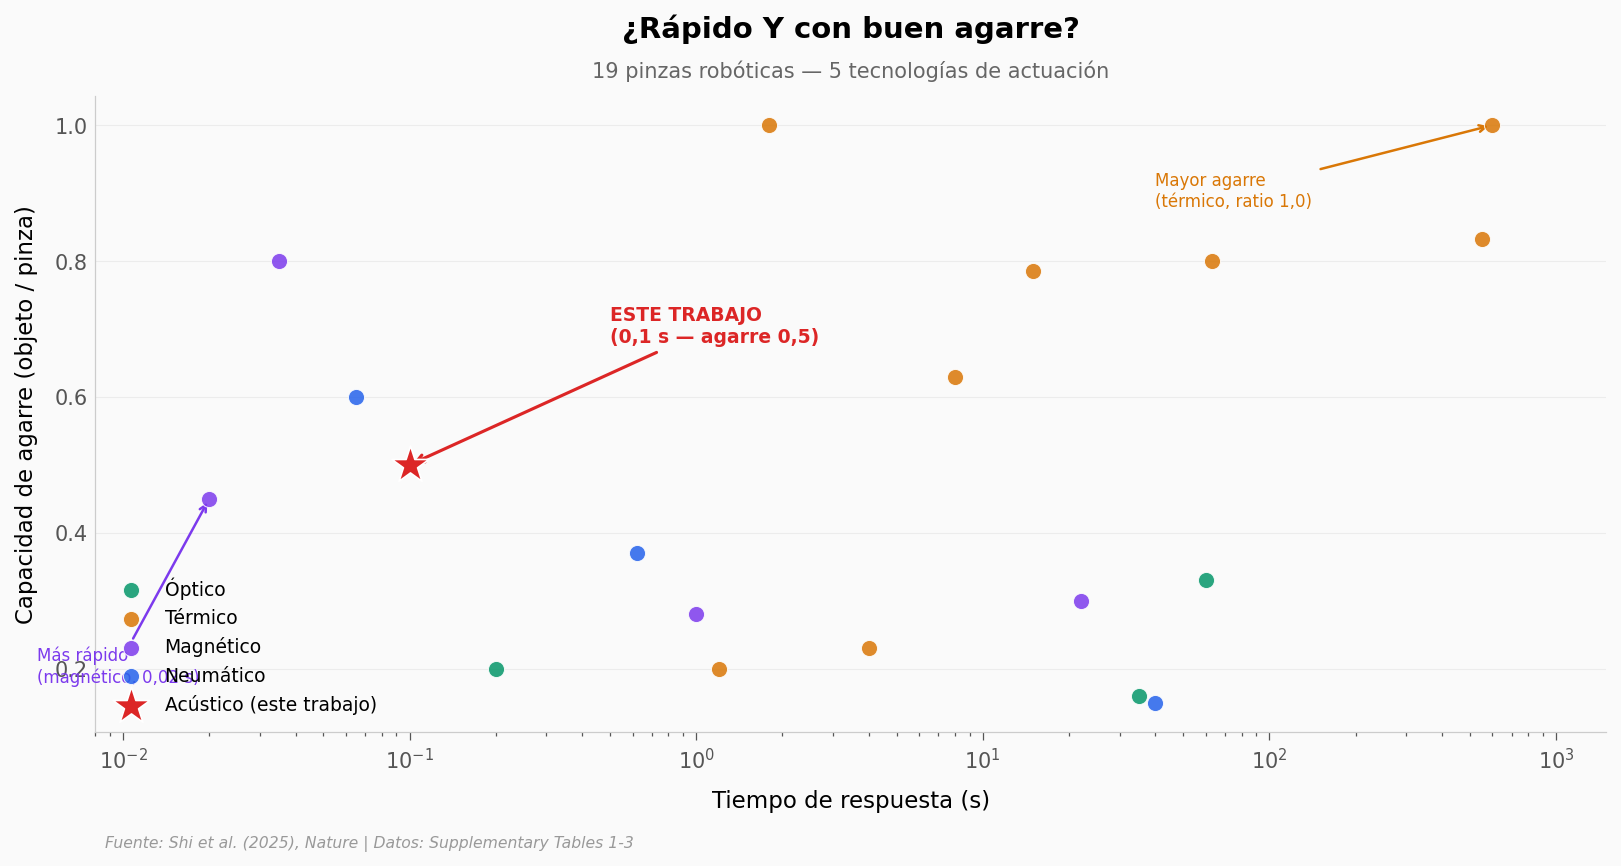

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Otros actuadores, agrupados por categoría
for cat in ['Light', 'Thermal', 'Magnetic', 'Pneumatic']:
    mask = (grippers['category'] == cat) & (grippers['is_this_work'] == 'no')
    subset = grippers[mask]
    ax.scatter(subset['response_time_s'], subset['gripping_ability_object_gripper'],
               color=COLORES[cat], s=60, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=5,
               label=TRADUCCION[cat])

# Este trabajo — estrella grande
tw = grippers[grippers['is_this_work'] == 'yes'].iloc[0]
ax.scatter(tw['response_time_s'], tw['gripping_ability_object_gripper'],
           color=COLORES['Acoustic'], s=350, marker='*', zorder=10,
           edgecolors='white', linewidths=0.8,
           label='Acústico (este trabajo)')

ax.set_xscale('log')
ax.set_xlabel('Tiempo de respuesta (s)', fontsize=11)
ax.set_ylabel('Capacidad de agarre (objeto / pinza)', fontsize=11)
ax.set_title('¿Rápido Y con buen agarre?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '19 pinzas robóticas — 5 tecnologías de actuación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotaciones inline para los puntos clave
ax.annotate('Más rápido\n(magnético, 0,02 s)',
            xy=(0.02, 0.45), xytext=(0.005, 0.18),
            fontsize=8, color=COLORES['Magnetic'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Magnetic'], lw=1.2))
ax.annotate('Mayor agarre\n(térmico, ratio 1,0)',
            xy=(600, 1.0), xytext=(40, 0.88),
            fontsize=8, color=COLORES['Thermal'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Thermal'], lw=1.2))
ax.annotate('ESTE TRABAJO\n(0,1 s — agarre 0,5)',
            xy=(0.1, 0.5), xytext=(0.5, 0.68),
            fontsize=9, fontweight='bold', color=COLORES['Acoustic'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Acoustic'], lw=1.5))

ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.set_xlim(0.008, 1500)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/grippers_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

Los magnéticos dominan la velocidad — el más rápido responde en 0,02 s, cinco veces menos que este trabajo (0,1 s). Los térmicos alcanzan el mayor agarre (ratio 1,0), pero el más rápido entre ellos necesita 1,2 s.

¿Dónde queda el acústico? En medio. No gana en ninguna dimensión. Pero es el **único** que funciona con ultrasonido: inalámbrico, capaz de atravesar tejido biológico, sin necesidad de campos magnéticos ni calentamiento.

El punto no es ser el mejor en una métrica. Es abrir un paradigma nuevo.

## ¿Y la fuerza?

Un músculo artificial necesita generar fuerza suficiente para su peso. Veamos dónde se ubica este entre 15 actuadores.

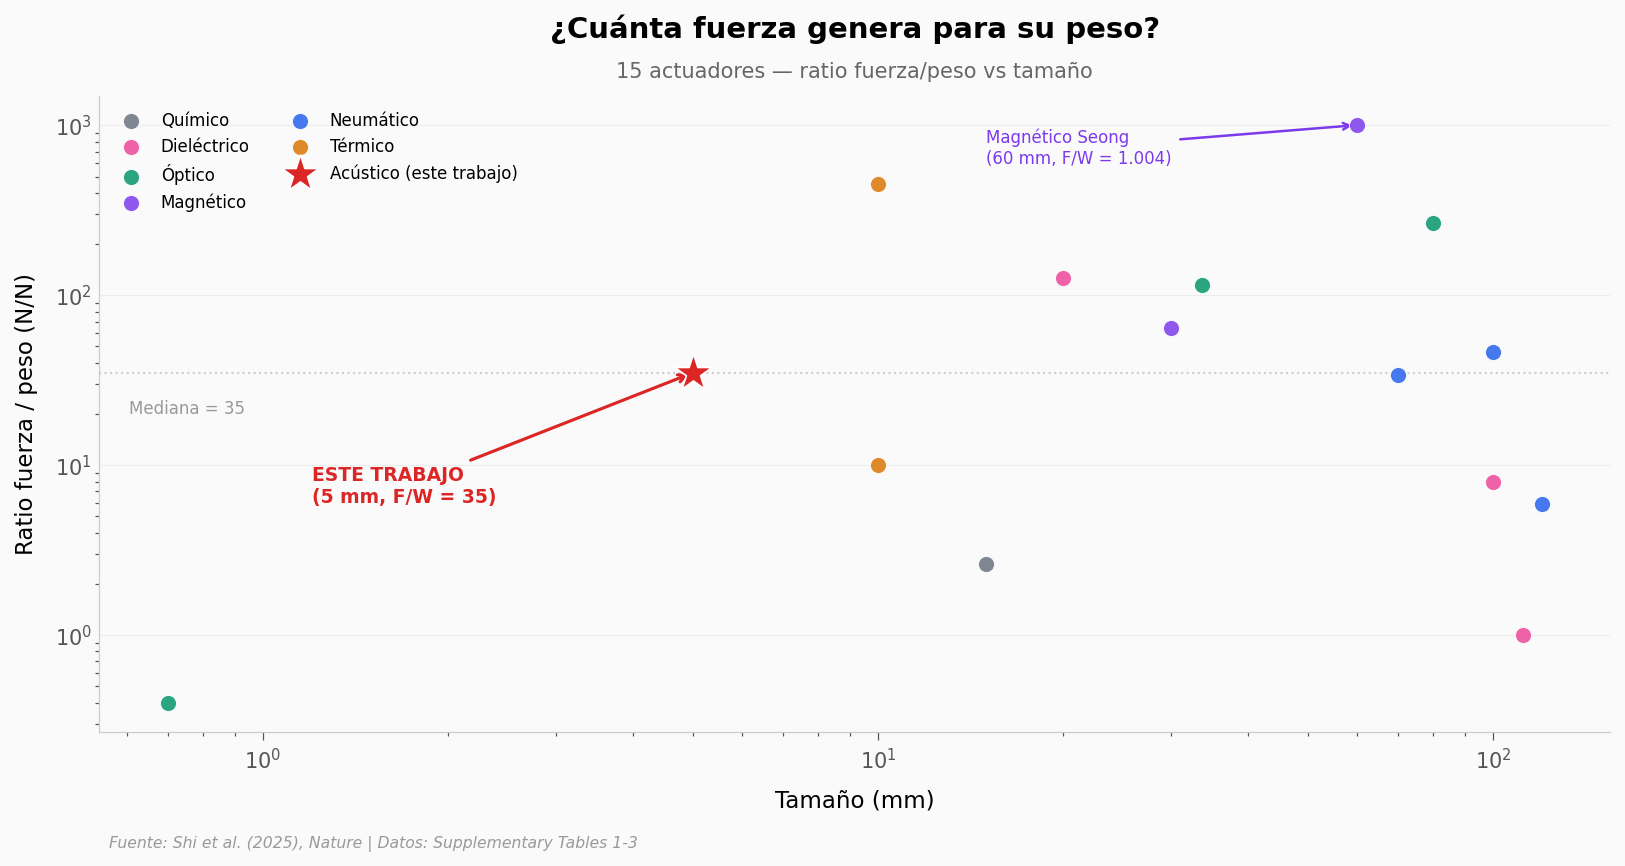

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Otros actuadores
for cat in force_wt['category'].unique():
    mask = (force_wt['category'] == cat) & (force_wt['is_this_work'] == 'no')
    subset = force_wt[mask]
    if len(subset) > 0:
        ax.scatter(subset['size_mm'], subset['force_to_weight_ratio_N_N'],
                   color=COLORES[cat], s=60, alpha=0.85,
                   edgecolors='white', linewidths=0.5, zorder=5,
                   label=TRADUCCION[cat])

# Este trabajo
tw2 = force_wt[force_wt['is_this_work'] == 'yes'].iloc[0]
ax.scatter(tw2['size_mm'], tw2['force_to_weight_ratio_N_N'],
           color=COLORES['Acoustic'], s=350, marker='*', zorder=10,
           edgecolors='white', linewidths=0.8,
           label='Acústico (este trabajo)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Tamaño (mm)', fontsize=11)
ax.set_ylabel('Ratio fuerza / peso (N/N)', fontsize=11)
ax.set_title('¿Cuánta fuerza genera para su peso?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '15 actuadores — ratio fuerza/peso vs tamaño',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Línea de mediana
ax.axhline(y=35, color='#BBBBBB', linewidth=1, linestyle=':', alpha=0.7, zorder=1)
ax.text(0.02, 0.50, 'Mediana = 35', fontsize=8, color='#999999',
        transform=ax.transAxes)

# Anotaciones
ax.annotate('ESTE TRABAJO\n(5 mm, F/W = 35)',
            xy=(5, 35), xytext=(1.2, 6),
            fontsize=9, fontweight='bold', color=COLORES['Acoustic'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Acoustic'], lw=1.5))

ax.annotate('Magnético Seong\n(60 mm, F/W = 1.004)',
            xy=(60, 1004), xytext=(15, 600),
            fontsize=8, color=COLORES['Magnetic'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Magnetic'], lw=1.2))

ax.legend(fontsize=8, loc='upper left', framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fuerza_peso_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

Fuerza/peso de 35 — posición 8 de 15 en el benchmark, rango medio. A tamaño similar (5 mm), supera al químico Yang (2,61) y al térmico Schubert (10), pero pierde contra el dieléctrico Sirbu (127 a 20 mm) y el térmico Yao (450 a 10 mm).

Un rendimiento medio, coherente con una tecnología en primera generación. Los líderes llevan décadas de optimización.

## ¿Y puede moverse?

La prueba definitiva: una raya-robot (stingraybot) de 50 mm que nada impulsada por ultrasonido. Comparémosla con 39 nadadores robóticos publicados.

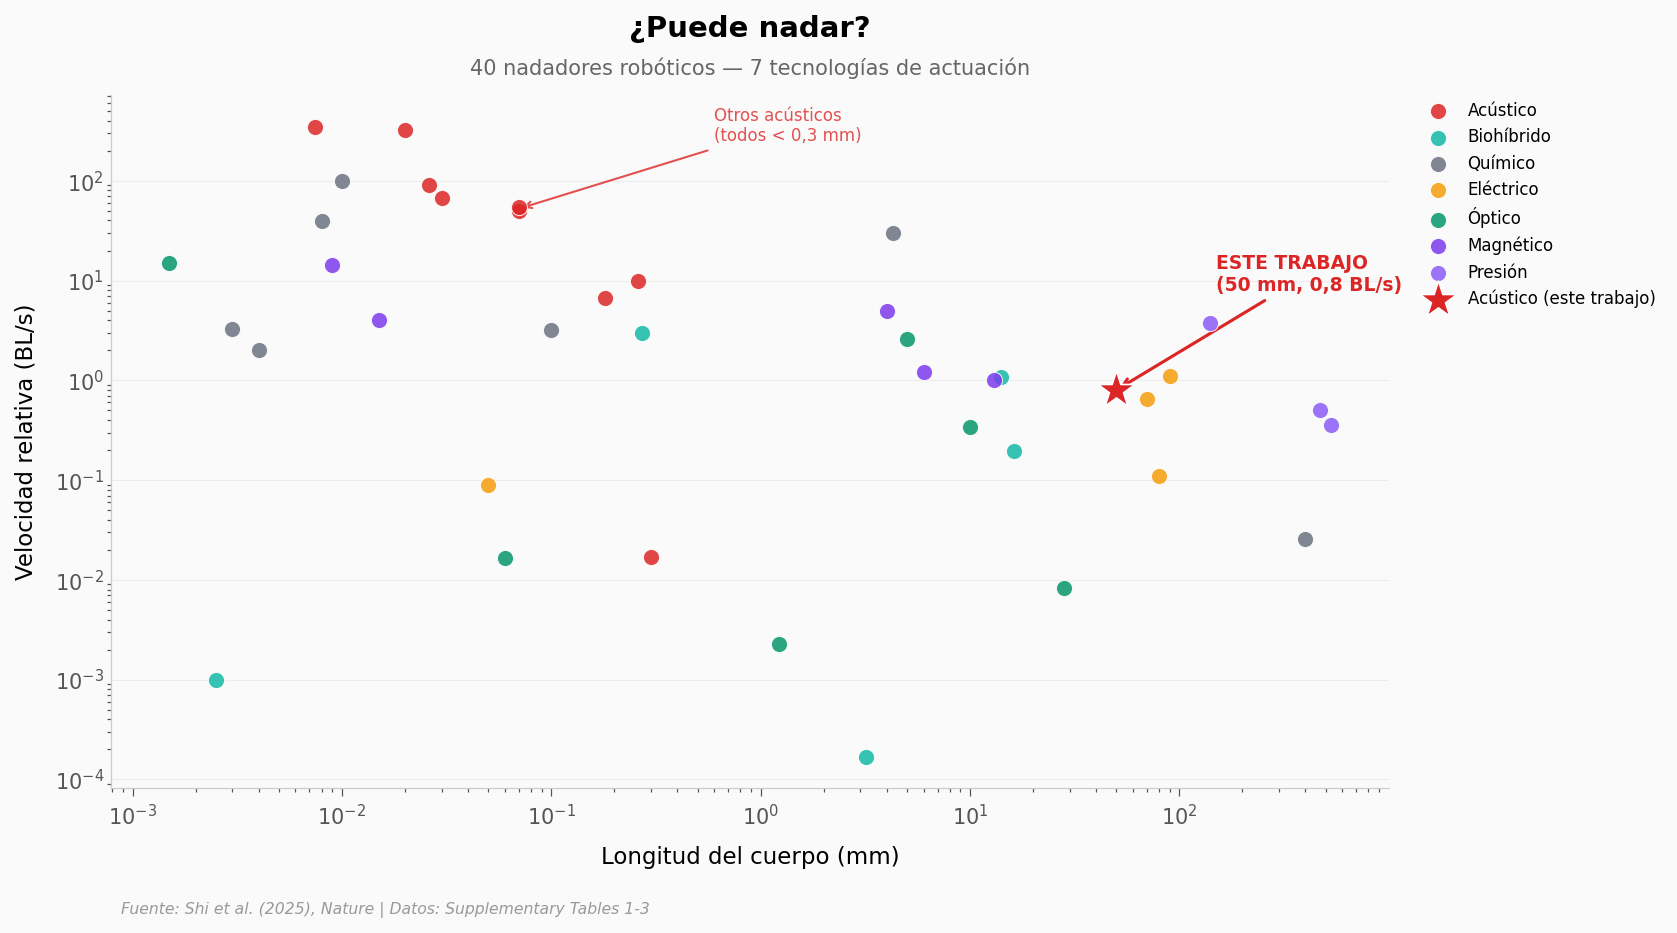

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

# Otros nadadores
for cat in swimmers['category'].unique():
    mask = (swimmers['category'] == cat) & (swimmers['is_this_work'] == 'no')
    subset = swimmers[mask]
    if len(subset) > 0:
        ax.scatter(subset['body_length_mm'], subset['relative_speed_BL_s'],
                   color=COLORES[cat], s=60, alpha=0.85,
                   edgecolors='white', linewidths=0.5, zorder=5,
                   label=TRADUCCION[cat])

# Este trabajo
tw3 = swimmers[swimmers['is_this_work'] == 'yes'].iloc[0]
ax.scatter(tw3['body_length_mm'], tw3['relative_speed_BL_s'],
           color=COLORES['Acoustic'], s=350, marker='*', zorder=10,
           edgecolors='white', linewidths=0.8,
           label='Acústico (este trabajo)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Longitud del cuerpo (mm)', fontsize=11)
ax.set_ylabel('Velocidad relativa (BL/s)', fontsize=11)
ax.set_title('¿Puede nadar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '40 nadadores robóticos — 7 tecnologías de actuación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotaciones
ax.annotate('ESTE TRABAJO\n(50 mm, 0,8 BL/s)',
            xy=(50, 0.8), xytext=(150, 8),
            fontsize=9, fontweight='bold', color=COLORES['Acoustic'],
            arrowprops=dict(arrowstyle='->', color=COLORES['Acoustic'], lw=1.5))

ax.annotate('Otros acústicos\n(todos < 0,3 mm)',
            xy=(0.07, 52.5), xytext=(0.6, 250),
            fontsize=8, color=COLORES['Acoustic'], alpha=0.8,
            arrowprops=dict(arrowstyle='->', color=COLORES['Acoustic'], lw=1, alpha=0.8))

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, framealpha=0.9, ncol=1)
plt.subplots_adjust(right=0.78)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/nadadores_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

El salto es brutal. Todos los nadadores acústicos anteriores son microscópicos — la mediana está en 0,07 mm (70 micrómetros). Este trabajo mide 50 mm: **714 veces más grande** que la mediana acústica.

A 50 mm y 0,8 longitudes de cuerpo por segundo (BL/s), supera a 7 de los 11 nadadores mayores de 10 mm del benchmark. Pierde contra Chi (presión, 3,74 BL/s), Ye (eléctrico, 1,1), Yong (biohíbrido, 1,07) y Lum (magnético, 1,0) — los 4 nadadores >10 mm más rápidos del benchmark.

## 714 veces

Eso es lo que separa este músculo acústico de la mediana de nadadores acústicos previos (0,07 mm → 50 mm). Casi tres órdenes de magnitud, de escala micrométrica a centimétrica.

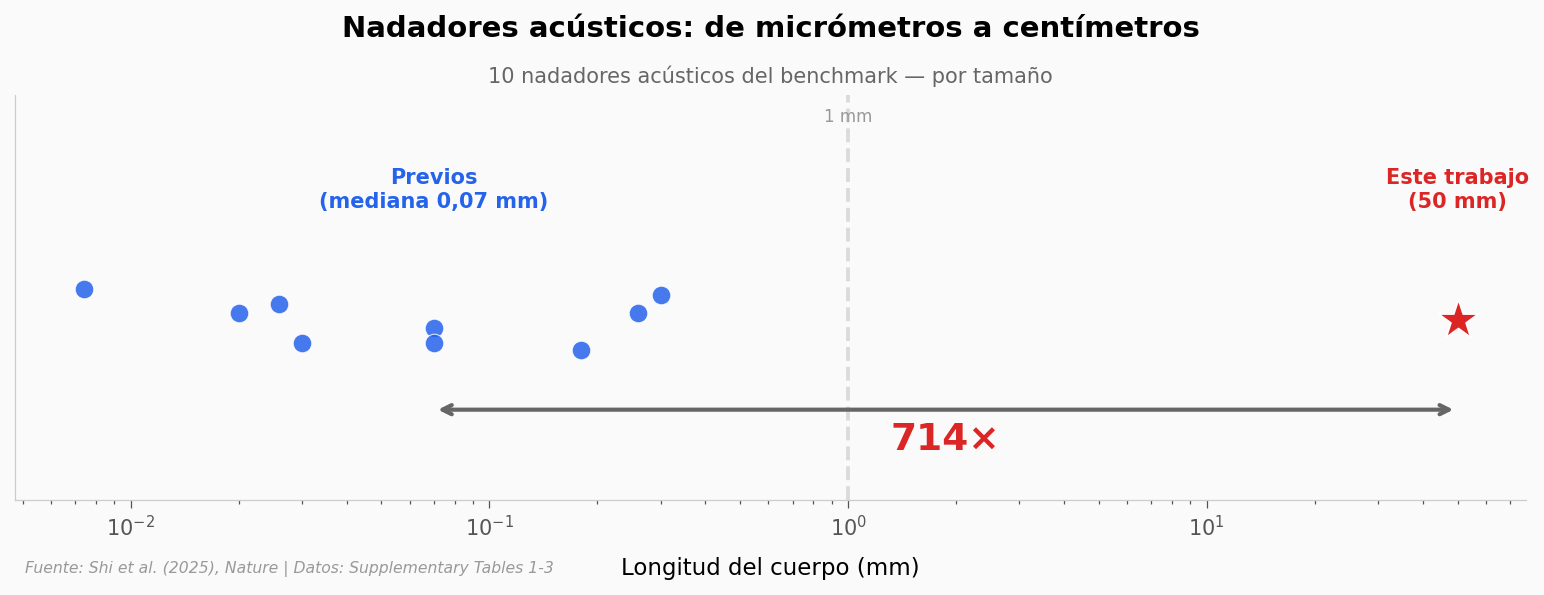

In [5]:
fig, ax = plt.subplots(figsize=(13, 3.5))

acoustic_all = swimmers[swimmers['category'] == 'Acoustic'].copy()
acoustic_others = acoustic_all[acoustic_all['is_this_work'] == 'no']
tw_swim = acoustic_all[acoustic_all['is_this_work'] == 'yes'].iloc[0]

# Micronadadores previos — dispersión con jitter vertical
np.random.seed(42)
y_jitter = np.random.uniform(-0.15, 0.15, len(acoustic_others))
ax.scatter(acoustic_others['body_length_mm'], y_jitter,
           color='#2563EB', s=80, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# Este trabajo — estrella
ax.scatter(tw_swim['body_length_mm'], 0,
           color=COLORES['Acoustic'], s=400, marker='*',
           edgecolors='white', linewidths=0.8, zorder=10)

ax.set_xscale('log')
ax.set_ylim(-0.8, 1.0)
ax.set_yticks([])
ax.set_xlabel('Longitud del cuerpo (mm)', fontsize=11)

# Etiquetas de grupo
ax.text(0.07, 0.5, 'Previos\n(mediana 0,07 mm)',
        fontsize=10, color='#2563EB', ha='center', fontweight='bold')
ax.text(50, 0.5, 'Este trabajo\n(50 mm)',
        fontsize=10, color=COLORES['Acoustic'], ha='center', fontweight='bold')

# Flecha bidireccional 714×
median_x = acoustic_others['body_length_mm'].median()
ax.annotate('', xy=(50, -0.4), xytext=(median_x, -0.4),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2))
# Texto centrado en la media geométrica (log-scale midpoint)
geo_mean = np.sqrt(median_x * 50)
ax.text(geo_mean, -0.58, '714\u00d7', fontsize=18, fontweight='bold',
        color=COLORES['Acoustic'], ha='center')

# Líneas de referencia
ax.axvline(x=1, linestyle='--', color='#BBBBBB', alpha=0.5, zorder=1)
ax.text(1, 0.88, '1 mm', fontsize=8, color='#999999', ha='center')

ax.set_title('Nadadores acústicos: de micrómetros a centímetros',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '10 nadadores acústicos del benchmark — por tamaño',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escala_acusticos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Tiempo de respuesta de 100 ms en agarre | ✅ | Tabla 1: 0,1 s. El abstract dice "sub-100 ms" — los datos muestran exactamente 100 ms (borderline) |
| Único actuador acústico entre 19 pinzas comparadas | ✅ | 1 de 19 entradas en Tabla 1. Sin precedente acústico en la comparativa |
| Ratio fuerza/peso de 35, rango medio del benchmark | ✅ | Tabla 2: F/W = 35, posición 8 de 15, exactamente la mediana |
| 714 veces más grande que la mediana de nadadores acústicos | ✅ | Mediana otros acústicos: 0,07 mm. Este trabajo: 50 mm. 50 / 0,07 = 714 |
| Velocidad competitiva entre nadadores grandes (>10 mm) | ✅ | 0,8 BL/s supera a 7 de 11 nadadores >10 mm. Pierde contra presión Chi (3,74) y eléctrico Ye (1,1) |
| Paradigma acústico nuevo (inalámbrico, biocompatible, programable) | ⚠️ | Verificado como nuevo paradigma en los 3 benchmarks. Las claims de biocompatibilidad y programabilidad vienen del texto principal — no verificables solo con estos datos |

> **Limitaciones:** Los datos analizados son benchmarks de supplementary, no datos experimentales primarios. Las métricas de cada estudio pueden no ser directamente comparables (diferentes condiciones, definiciones de agarre, tipos de fluido). Este trabajo reporta primera generación — todas las métricas podrían mejorar con iteraciones posteriores.

## Ahora tú

1. **¿Cuántas tecnologías compiten en las 3 dimensiones?** Cruza las categorías de las 3 tablas. ¿Alguna otra aparece en agarre, fuerza Y natación? Prueba `set(grippers['category']) & set(force_wt['category']) & set(swimmers['category'])`

2. **¿Qué pasa si solo comparamos actuadores de 1-20 mm?** Filtra la Tabla 2 por tamaño: `force_wt[force_wt['size_mm'].between(1, 20)]`. ¿Cambia la posición relativa del acústico?

3. **¿Existe un frente de Pareto en la Tabla 1?** Un gripper está en el frente de Pareto si ningún otro es tanto más rápido como mejor en agarre. ¿Cuántos grippers no están dominados?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué tecnologías compiten en las 3 dimensiones?

cats_grip = set(grippers['category'].unique())
cats_force = set(force_wt['category'].unique())
cats_swim = set(swimmers['category'].unique())
todas = cats_grip | cats_force | cats_swim

en_3 = cats_grip & cats_force & cats_swim
en_2_only = set()
en_1_only = set()

for cat in todas:
    count = sum([cat in cats_grip, cat in cats_force, cat in cats_swim])
    if count == 2:
        en_2_only.add(cat)
    elif count == 1:
        en_1_only.add(cat)

print('=== Tecnologías por número de benchmarks ===')
print(f'\nEn las 3 tablas ({len(en_3)}):')
for cat in sorted(en_3):
    print(f'  {TRADUCCION[cat]}')
print(f'\nEn 2 de 3 tablas ({len(en_2_only)}):')
for cat in sorted(en_2_only):
    tablas = []
    if cat in cats_grip: tablas.append('agarre')
    if cat in cats_force: tablas.append('fuerza')
    if cat in cats_swim: tablas.append('natación')
    print(f'  {TRADUCCION[cat]} ({", ".join(tablas)})')
if en_1_only:
    print(f'\nEn solo 1 tabla ({len(en_1_only)}):')
    for cat in sorted(en_1_only):
        tablas = []
        if cat in cats_grip: tablas.append('agarre')
        if cat in cats_force: tablas.append('fuerza')
        if cat in cats_swim: tablas.append('natación')
        print(f'  {TRADUCCION[cat]} ({", ".join(tablas)})')

print('\n--- Nota ---')
print(f'{len(en_3)} tecnologías aparecen en las 3 tablas.')
print('Pero cada entrada es un dispositivo diferente de un laboratorio diferente.')
print('Este trabajo es UNA plataforma que compite en las 3 dimensiones.')

=== Tecnologías por número de benchmarks ===

En las 3 tablas (3):
  Acústico
  Óptico
  Magnético

En 2 de 3 tablas (3):
  Químico (fuerza, natación)
  Neumático (agarre, fuerza)
  Térmico (agarre, fuerza)

En solo 1 tabla (4):
  Biohíbrido (natación)
  Dieléctrico (fuerza)
  Eléctrico (natación)
  Presión (natación)

--- Nota ---
3 tecnologías aparecen en las 3 tablas.
Pero cada entrada es un dispositivo diferente de un laboratorio diferente.
Este trabajo es UNA plataforma que compite en las 3 dimensiones.


## Fuentes

**Paper**: [Ultrasound-driven programmable artificial muscles](https://doi.org/10.1038/s41586-025-09650-3)
*Nature, 2025-10-30*

**Datos**: [Supplementary Tables 1-3 (SI PDF)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-025-09650-3/MediaObjects/41586_2025_9650_MOESM1_ESM.pdf)

*6 afirmaciones verificadas contra estas fuentes*